# **Tutorial 2**


## Imports

In [ ]:
import numpy as np # arrays, array operations
import scipy.stats as stats # statistics
from google.colab import files
import matplotlib.pyplot as plt # plot graphs
import pandas as pd #dataframes
import io
import xarray as xr #multidimensional dataframes


In [4]:
#preliz
!pip install preliz

import preliz as pz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 513.9/513.9 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.6/171.6 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 17.6 MB/s eta 0:00:00
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: numba
    Found existing installation: numba 0.60.0
    Uninstalling numba-0.60.0:
      Successfully uninstalled numba-0.60.0


## Bayes therom example

Simulating data

In [6]:
# Observed data
n = 20
z = 3

print(f"In a pilot study, {z} of {n} patients had the event of interest.")
print(f"Observed proportion = {z/n:.2f}")

In a pilot study, 3 of 20 patients had the event of interest.
Observed proportion = 0.15


Cell 2 — Patient-level data for sequential updating

In [7]:
# One possible patient-level dataset with 3 events out of 20
data = np.array([1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
                 0, 1, 0, 0, 0, 0, 0, 0, 0, 0])

print(data)
print(f"Check: total events = {np.sum(data)}")

[1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
Check: total events = 3


Cell 3 — Likelihood for the observed data


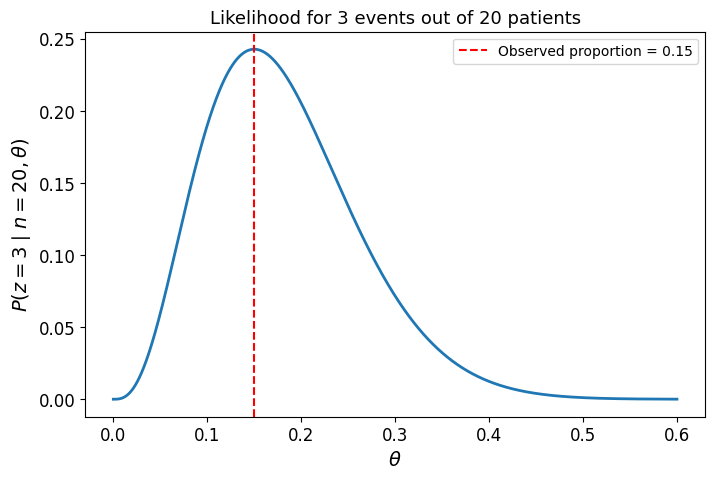

In [8]:
theta = np.linspace(0, 0.6, 2000)

likelihood = stats.binom.pmf(z, n, theta)

plt.figure(figsize=(8, 5))
plt.plot(theta, likelihood, linewidth=2)
plt.axvline(z/n, color='r', linestyle='--', label=f'Observed proportion = {z/n:.2f}')

plt.xlabel(r'$\theta$', fontsize=14)
plt.ylabel(r'$P(z=3 \mid n=20,\theta)$', fontsize=14)
plt.title('Likelihood for 3 events out of 20 patients', fontsize=13)
plt.legend()

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

Cell 4 — Story 1: rare adverse event prior

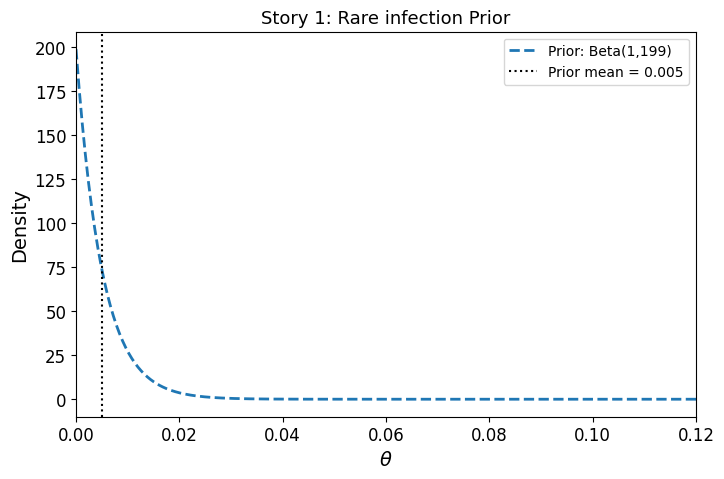

In [24]:
# Story 1 prior: rare adverse event
alpha1, beta1 = 1, 199   # prior mean = 0.005

prior1 = pz.Beta(alpha1, beta1).pdf(theta)
prior_mean1 = (alpha1) / (alpha1 + beta1)
plt.figure(figsize=(8, 5))
plt.plot(theta, prior1, '--', linewidth=2, label='Prior: Beta(1,199)')
plt.axvline(prior_mean1, color='k', linestyle=':', label=f'Prior mean = {prior_mean1:.3f}')

plt.xlim([0, 0.12])
plt.xlabel(r'$\theta$', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.title('Story 1: Rare infection Prior', fontsize=13)
plt.legend()

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()



/usr/local/lib/python3.12/dist-packages/pytensor/tensor/xlogx.py:47: RuntimeWarning: divide by zero encountered in log
  return x * np.log(y)


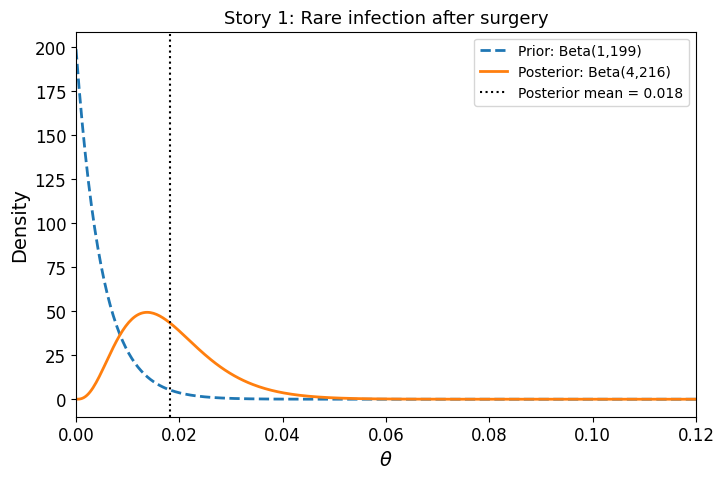

Story 1 posterior mean = 0.0182


In [25]:
# Story 1 prior: rare adverse event
alpha1, beta1 = 1, 199   # prior mean = 0.005

prior1 = pz.Beta(alpha1, beta1).pdf(theta)
posterior1 = pz.Beta(alpha1 + z, beta1 + (n - z)).pdf(theta)

posterior1_mean = (alpha1 + z) / (alpha1 + beta1 + n)

plt.figure(figsize=(8, 5))
plt.plot(theta, prior1, '--', linewidth=2, label='Prior: Beta(1,199)')
plt.plot(theta, posterior1, linewidth=2, label='Posterior: Beta(4,216)')
plt.axvline(posterior1_mean, color='k', linestyle=':', label=f'Posterior mean = {posterior1_mean:.3f}')

plt.xlim([0, 0.12])
plt.xlabel(r'$\theta$', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.title('Story 1: Rare infection after surgery', fontsize=13)
plt.legend()

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

print(f"Story 1 posterior mean = {posterior1_mean:.4f}")

Cell 5 — Sequential updating for Story 1

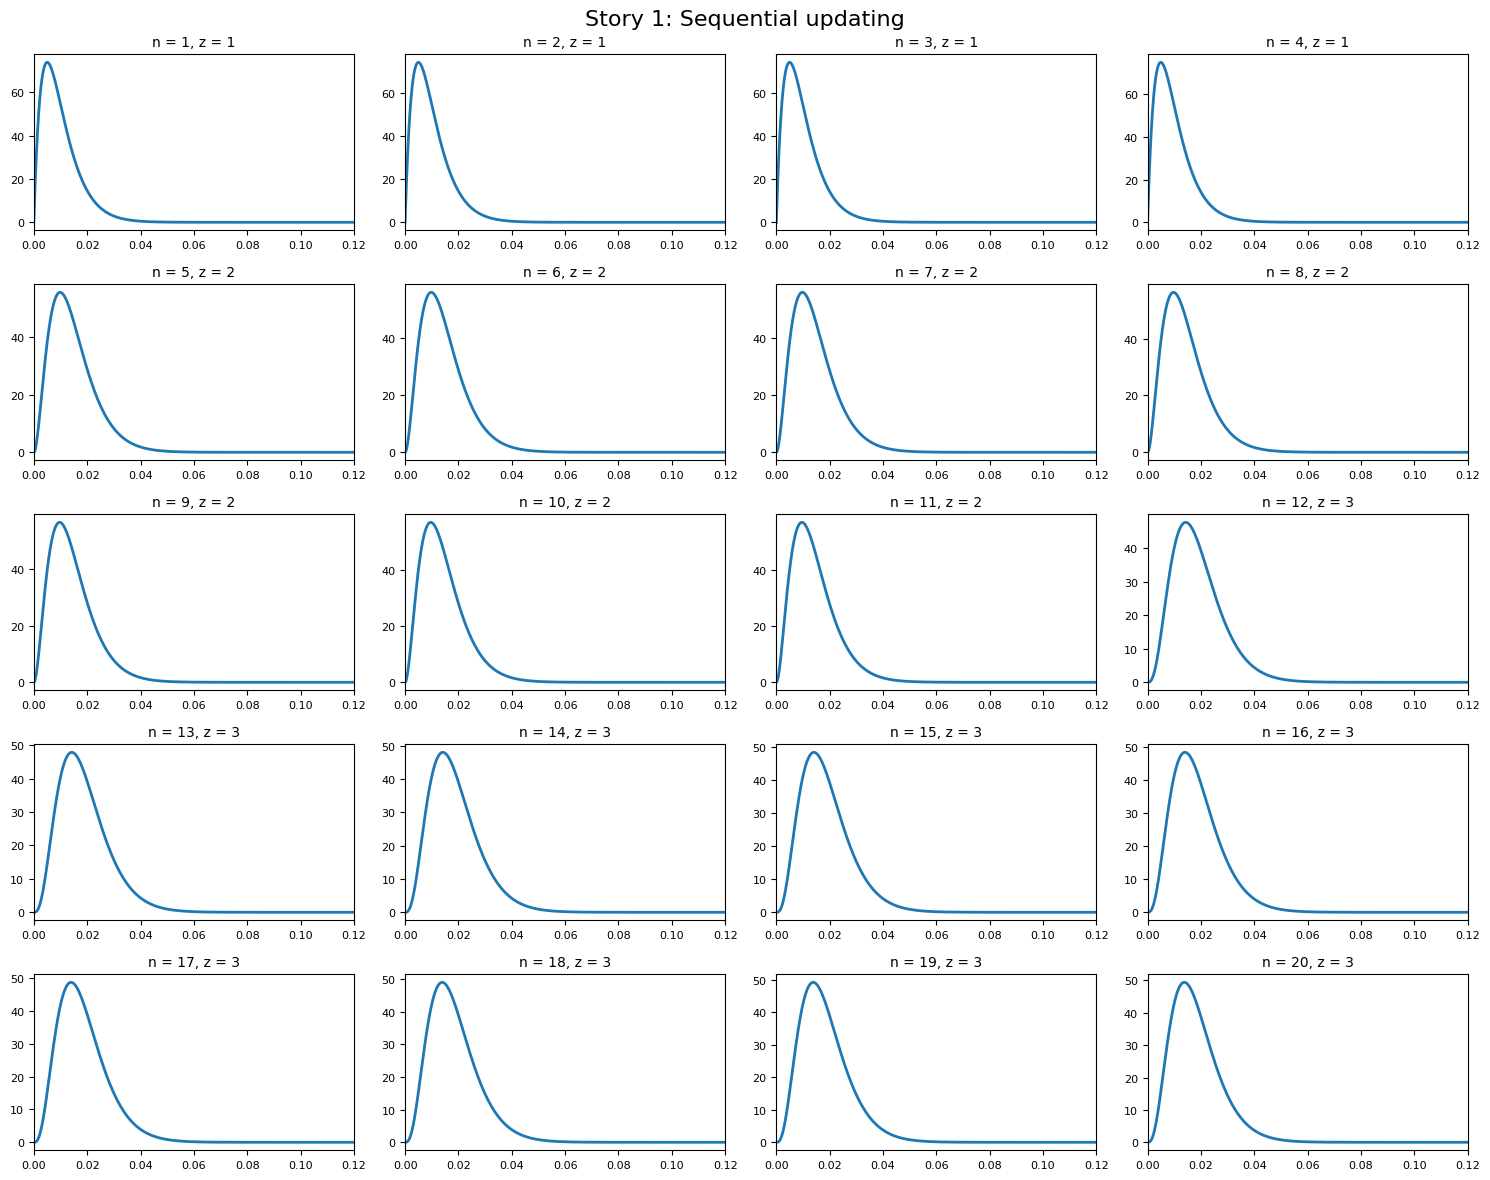

In [11]:
theta_zoom = np.linspace(0, 0.12, 2000)

plt.figure(figsize=(15, 12))

for idx in range(len(data)):
    z_so_far = np.sum(data[:idx + 1])

    posterior_seq = pz.Beta(alpha1 + z_so_far,
                            beta1 + (idx + 1 - z_so_far)).pdf(theta_zoom)

    plt.subplot(5, 4, idx + 1)
    plt.plot(theta_zoom, posterior_seq, linewidth=2)
    plt.title(f'n = {idx+1}, z = {z_so_far}', fontsize=10)
    plt.xlim([0, 0.12])

    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)

plt.suptitle('Story 1: Sequential updating', fontsize=16)
plt.tight_layout()
plt.show()

Cell 6 — Story 2: common event prior


/usr/local/lib/python3.12/dist-packages/pytensor/tensor/xlogx.py:47: RuntimeWarning: divide by zero encountered in log
  return x * np.log(y)


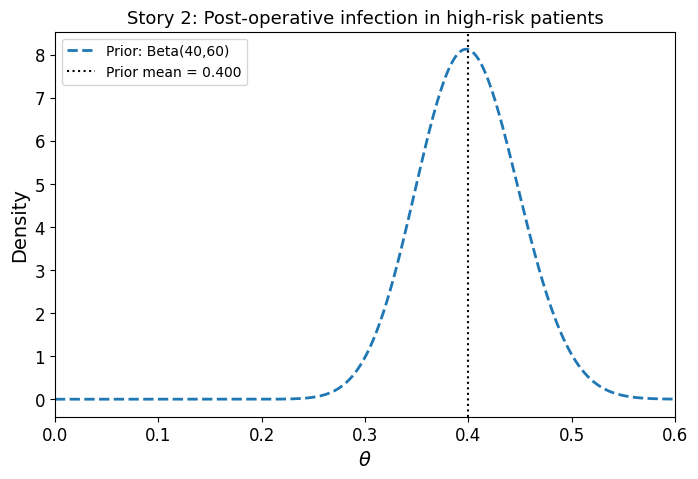

In [26]:
# Story 2 prior: common event
alpha2, beta2 = 40, 60   # prior mean = 0.40

prior2 = pz.Beta(alpha2, beta2).pdf(theta)

prior_mean2 = (alpha2) / (alpha2 + beta2)

plt.figure(figsize=(8, 5))
plt.plot(theta, prior2, '--', linewidth=2, label='Prior: Beta(40,60)')
plt.axvline(prior_mean2, color='k', linestyle=':', label=f'Prior mean = {prior_mean2:.3f}')

plt.xlim([0, 0.6])
plt.xlabel(r'$\theta$', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.title('Story 2: Post-operative infection in high-risk patients', fontsize=13)
plt.legend()

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


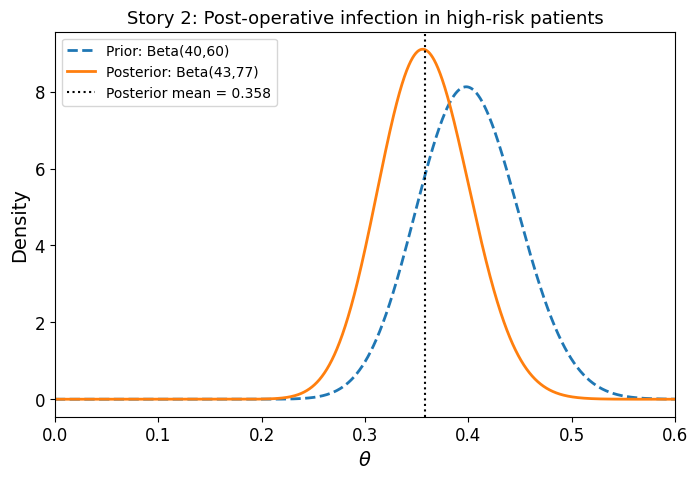

Story 2 posterior mean = 0.3583


In [12]:
# Story 2 prior: common event
alpha2, beta2 = 40, 60   # prior mean = 0.40

prior2 = pz.Beta(alpha2, beta2).pdf(theta)
posterior2 = pz.Beta(alpha2 + z, beta2 + (n - z)).pdf(theta)

posterior2_mean = (alpha2 + z) / (alpha2 + beta2 + n)

plt.figure(figsize=(8, 5))
plt.plot(theta, prior2, '--', linewidth=2, label='Prior: Beta(40,60)')
plt.plot(theta, posterior2, linewidth=2, label='Posterior: Beta(43,77)')
plt.axvline(posterior2_mean, color='k', linestyle=':', label=f'Posterior mean = {posterior2_mean:.3f}')

plt.xlim([0, 0.6])
plt.xlabel(r'$\theta$', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.title('Story 2: Post-operative infection in high-risk patients', fontsize=13)
plt.legend()

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

print(f"Story 2 posterior mean = {posterior2_mean:.4f}")

Cell 7 — Effect of the prior

Same data, different priors.

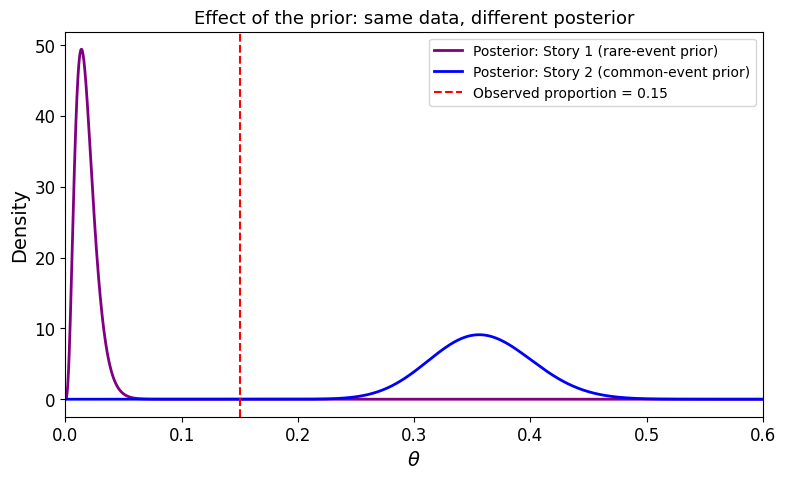

In [30]:
plt.figure(figsize=(9, 5))

plt.plot(theta, posterior1, color='purple', linewidth=2, label='Posterior: Story 1 (rare-event prior)')
# plt.plot(theta, prior1, '--', color='purple', linewidth=2, label='Prior: Beta(1,199)')
plt.plot(theta, posterior2, color='blue', linewidth=2, label='Posterior: Story 2 (common-event prior)')
# plt.plot(theta, prior2, '--', color='blue', linewidth=2, label='Prior 2: Beta(40,60)')

plt.axvline(z/n, color='r', linestyle='--', label=f'Observed proportion = {z/n:.2f}')

plt.xlim([0, 0.6])
plt.xlabel(r'$\theta$', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.title('Effect of the prior: same data, different posterior', fontsize=13)
plt.legend()

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

Cell 8 — Priors and posteriors side by side

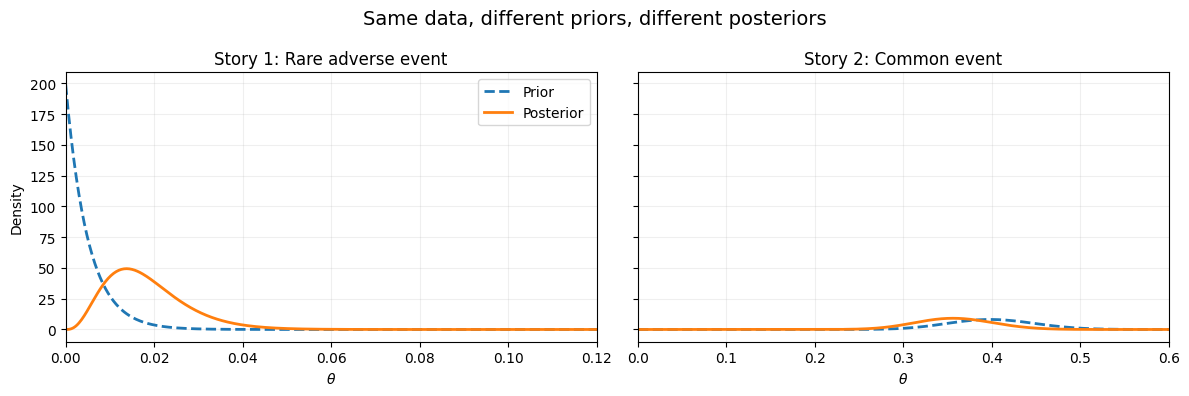

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Story 1
axes[0].plot(theta, prior1, '--', linewidth=2, label='Prior')
axes[0].plot(theta, posterior1, linewidth=2, label='Posterior')
axes[0].set_title('Story 1: Rare adverse event')
axes[0].set_xlim([0, 0.12])
axes[0].set_xlabel(r'$\theta$')
axes[0].grid(alpha=0.2)

# Story 2
axes[1].plot(theta, prior2, '--', linewidth=2, label='Prior')
axes[1].plot(theta, posterior2, linewidth=2, label='Posterior')
axes[1].set_title('Story 2: Common event')
axes[1].set_xlim([0, 0.6])
axes[1].set_xlabel(r'$\theta$')
axes[1].grid(alpha=0.2)

axes[0].set_ylabel('Density')
axes[0].legend()

plt.suptitle('Same data, different priors, different posteriors', fontsize=14)
plt.tight_layout()
plt.show()

Cell 9 — Effect of the likelihood

Here we keep the prior fixed and change only the amount of data.

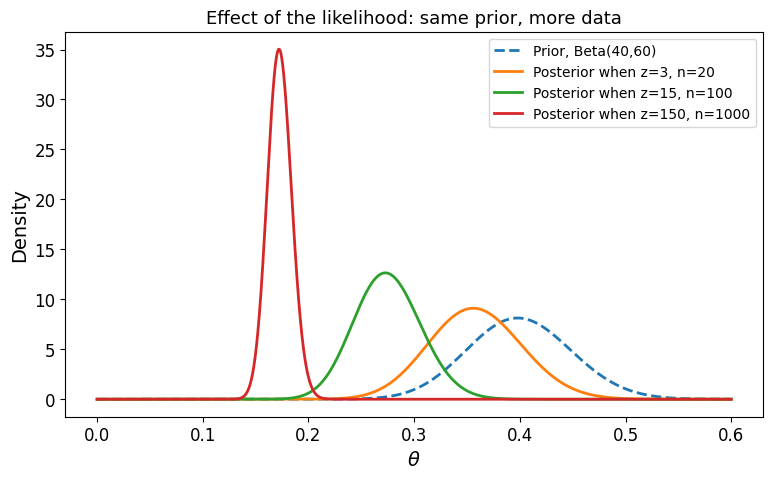

In [35]:
# Keep the same prior as Story 2 for a clearer visual
alpha_like, beta_like = 40, 60

datasets = [
    (3, 20),
    (15, 100),
    (150, 1000)
]

theta_like = np.linspace(0, 0.6, 2000)

plt.figure(figsize=(9, 5))

prior_like = pz.Beta(alpha_like, beta_like).pdf(theta_like)
plt.plot(theta_like, prior_like, '--', linewidth=2, label='Prior, Beta(40,60)')

for z_i, n_i in datasets:
    posterior_i = pz.Beta(alpha_like + z_i,
                          beta_like + (n_i - z_i)).pdf(theta_like)
    plt.plot(theta_like, posterior_i, linewidth=2, label=f'Posterior when z={z_i}, n={n_i}')

plt.xlabel(r'$\theta$', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.title('Effect of the likelihood: same prior, more data', fontsize=13)
plt.legend()

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

Cell 10 — Likelihood effect as separate panels

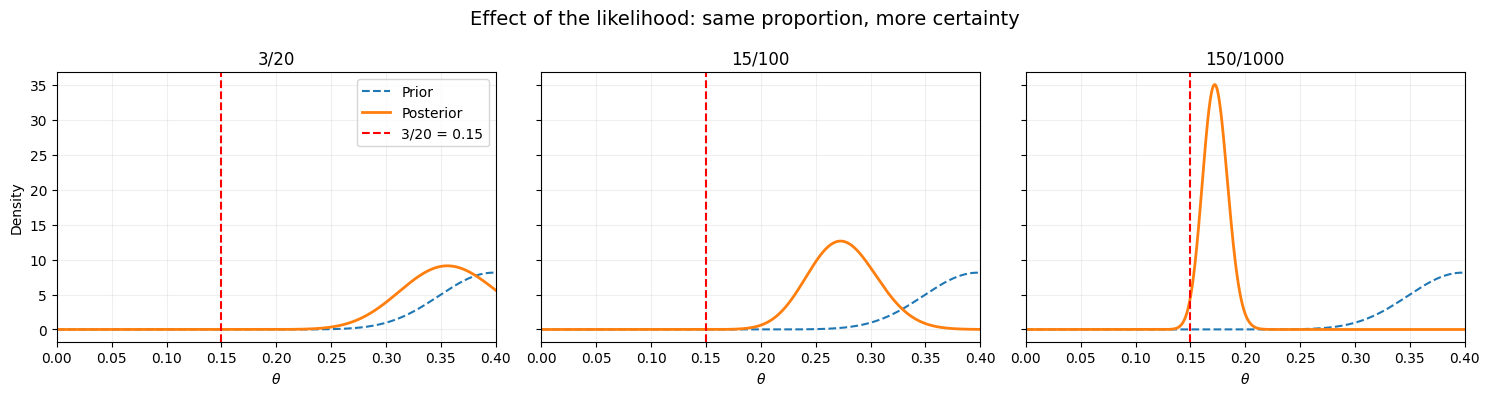

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (z_i, n_i) in zip(axes, datasets):
    posterior_i = pz.Beta(alpha_like + z_i,
                          beta_like + (n_i - z_i)).pdf(theta_like)

    ax.plot(theta_like, pz.Beta(alpha_like, beta_like).pdf(theta_like),
            '--', label='Prior')
    ax.plot(theta_like, posterior_i, linewidth=2, label='Posterior')
    ax.axvline(z_i/n_i, color='r', linestyle='--',
               label=f'{z_i}/{n_i} = {z_i/n_i:.2f}')

    ax.set_title(f'{z_i}/{n_i}')
    ax.set_xlim([0, 0.4])
    ax.set_xlabel(r'$\theta$')
    ax.grid(alpha=0.2)

axes[0].set_ylabel('Density')
axes[0].legend()

plt.suptitle('Effect of the likelihood: same proportion, more certainty', fontsize=14)
plt.tight_layout()
plt.show()

----

## Grid method

Creating the function

In [30]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import preliz as pz

def posterior_grid(theta_grid, z, n, alpha_prior, beta_prior):
    """
    Grid approximation of the posterior for a Beta-Binomial model.

    Parameters
    ----------
    theta_grid : np.ndarray
        Grid of possible theta values.
    z : int
        Number of observed events.
    n : int
        Number of trials.
    alpha_prior : float
        Alpha parameter of the Beta prior.
    beta_prior : float
        Beta parameter of the Beta prior.

    Returns
    -------
    theta_grid : np.ndarray
        Same grid of theta values.
    posterior : np.ndarray
        Normalized posterior density on the grid.
    """
    grid_points = len(theta_grid)

    # Prior on theta
    prior = pz.Beta(alpha_prior, beta_prior).pdf(theta_grid)

    # Likelihood for observing z events out of n
    likelihood = stats.binom.pmf(z, n, theta_grid)

    # Unnormalized posterior
    posterior = likelihood * prior

    # Normalize using numerical integration over the grid
    dx = (np.max(theta_grid) - np.min(theta_grid)) / grid_points
    posterior /= posterior.sum() * dx

    return theta_grid, posterior

Function call

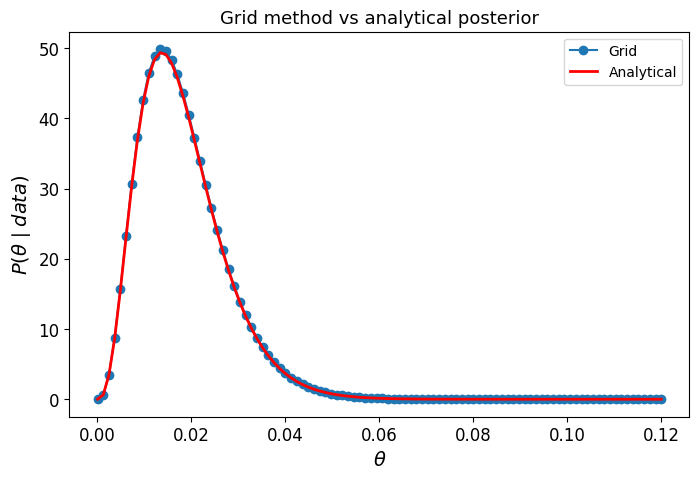

In [35]:
# Observed data
z = 3
n = 20

# Rare-event prior
alpha_prior = 1
beta_prior = 199

# Grid points
theta_grid = np.linspace(0.0001, 0.12, 100)

# Grid approximation
theta_grid, posterior_grid_values = posterior_grid(
    theta_grid, z, n, alpha_prior, beta_prior
)

# Analytical posterior
posterior_analytical = pz.Beta(alpha_prior + z, beta_prior + n - z).pdf(theta_grid)

# Plot comparison
plt.figure(figsize=(8, 5))
plt.plot(theta_grid, posterior_grid_values, 'o-', label='Grid')
plt.plot(theta_grid, posterior_analytical, 'red', linewidth=2, label='Analytical')

plt.xlabel(r'$\theta$', fontsize=14)
plt.ylabel(r'$P(\theta \mid data)$', fontsize=14)
plt.title('Grid method vs analytical posterior', fontsize=13)
plt.legend(loc='upper right')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()